# GBPUSD V. EURUSD

### IMPORT 

In [8]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE

### PARAMS

In [9]:
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Keep: Captures the short-term microstructure beta
Z_WINDOW = 100              # Keep: Fast rolling mean to fade bid/ask bounces

ENTRY_Z = 1.50              # TWEAKED: Raised from 1.25
EXIT_Z = -0.25              # Keep: Captures momentum past the mean
AR_LIMIT = 0.985            # TWEAKED: Tightened from 0.995
DANGER_THRESHOLD = 0.95     # TWEAKED: Raised from 0.90

### DESCRIPTIVE

built 9249 rows

=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=0.35 | B=0.14 bps


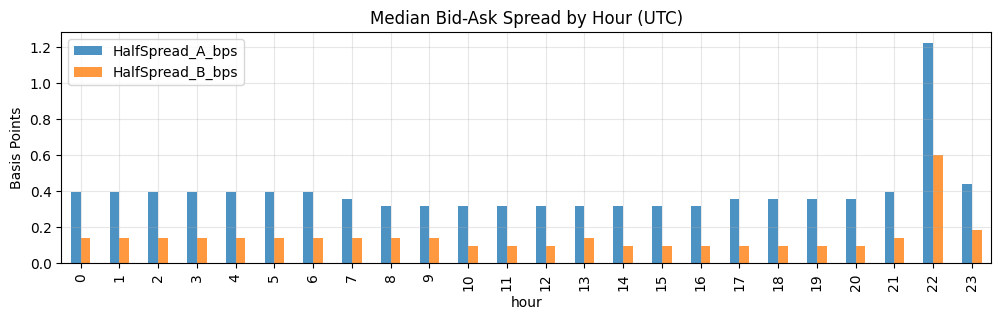


=== RETURN STATISTICS (Log Scale) ===
         Mean (bps)  Vol (bps)      Skew   Kurtosis
GBP/USD   -0.008784    2.95573 -0.784282  13.139728
EUR/USD   -0.023580    2.70587 -0.950764  15.990201

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


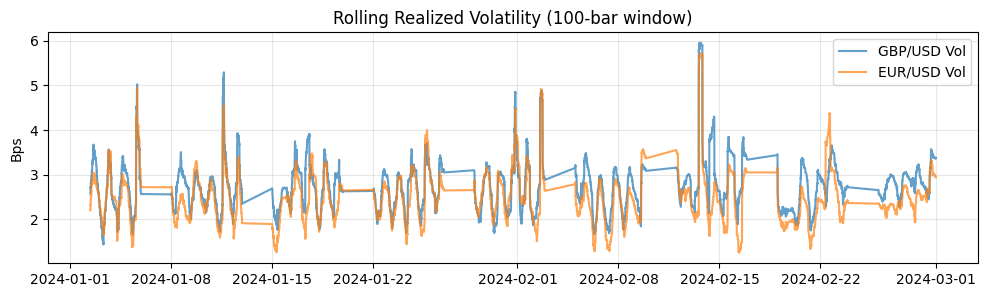

In [10]:
eda_months = ["202401", "202402"]
eda_files = [
    [f"../data/processed/gbpusd_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/gbpusd_dukascopy_bid_{m}.parquet" for m in eda_months],
    [f"../data/processed/eurusd_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/eurusd_dukascopy_bid_{m}.parquet" for m in eda_months],
]

# 2. Build 24-hours for the EDA
builder_eda = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24)) 
df_raw_eda = builder_eda.build(eda_files)

# 3. Run Descriptive Stats to see the Bar Chart
eda = DESCRIPTIVE(df_raw_eda, "GBP/USD", "EUR/USD")
eda.generate_full_eda()

### DATA

In [11]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/gbpusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/gbpusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eurusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 53489 rows


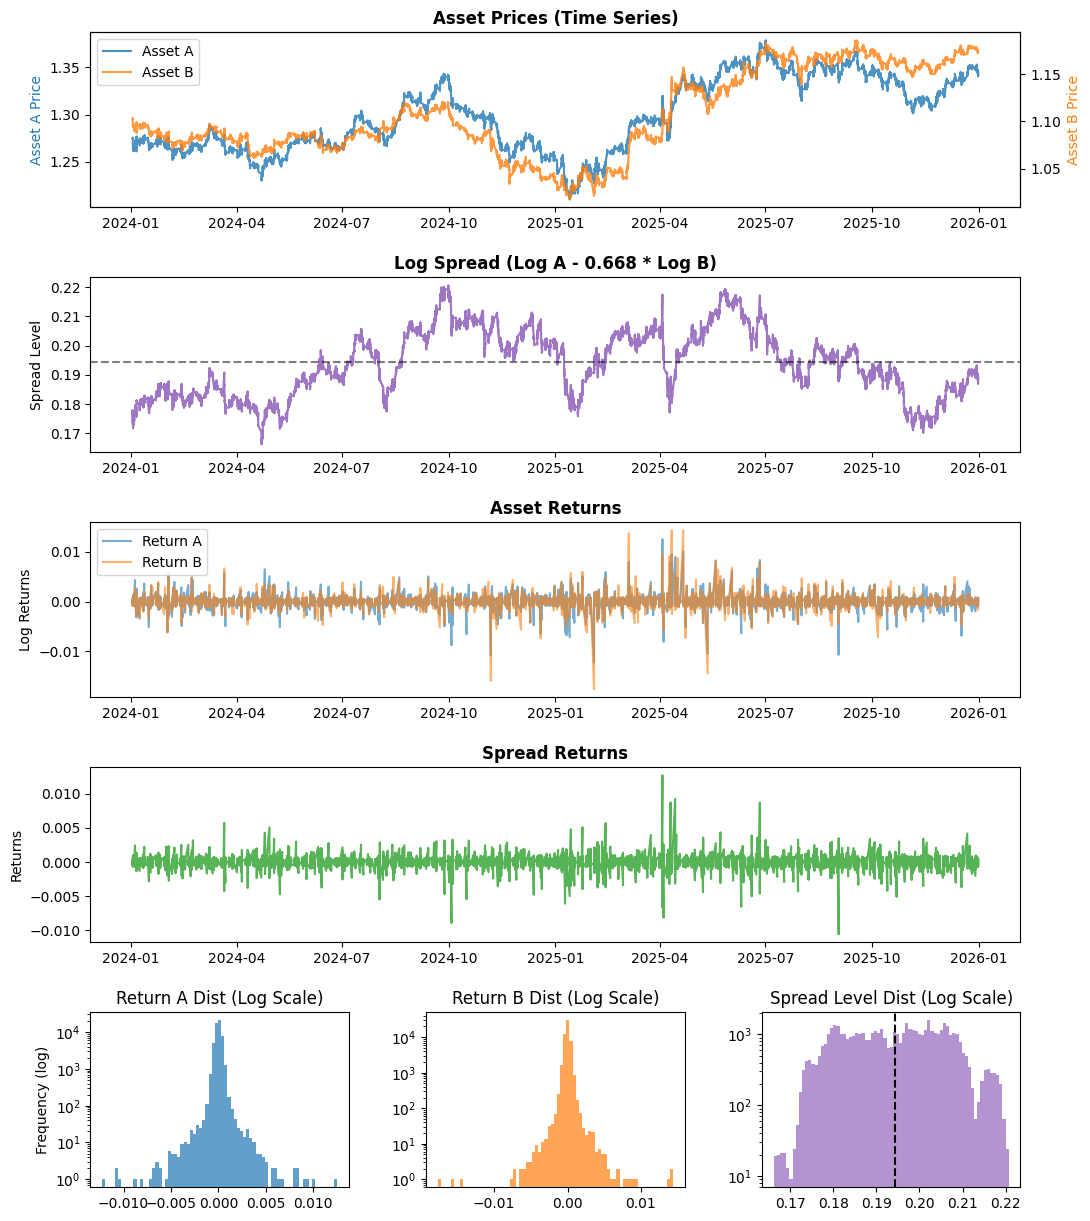

In [12]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(8, 16)) # Build all hours first
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE 


=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=0.30 | B=0.14 bps


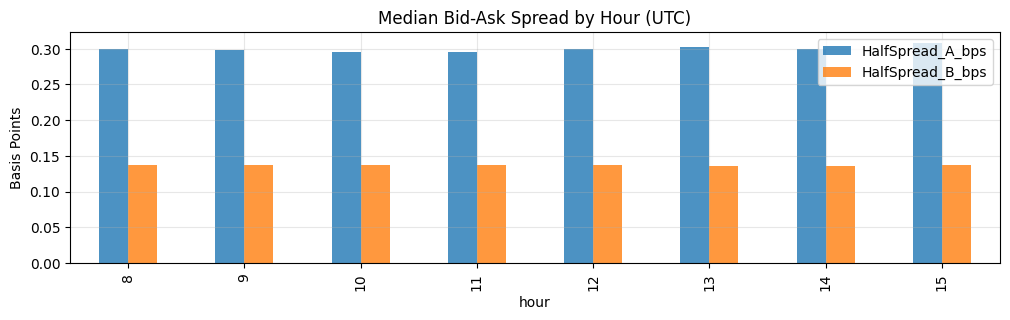


=== RETURN STATISTICS (Log Scale) ===
        Mean (bps)  Vol (bps)      Skew    Kurtosis
GBPUSD    0.010183   4.337133 -0.304389  102.071986
EURUSD    0.011904   4.404773 -0.219965  201.907391

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


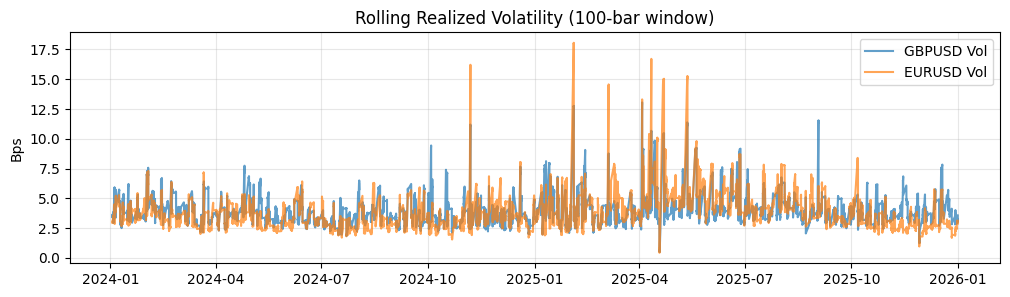

In [13]:
eda = DESCRIPTIVE(df, name_a="GBPUSD", name_b="EURUSD")
eda.generate_full_eda()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.1275 | half-life=1276.0 | β=0.6680

Rolling (2000-bar, step 200, n=258):
  p<0.05: 7.0% | p<0.10: 14.0%
  half-life: 84.4 (IQR 57–131)
  β: 0.9048 ±0.3911 [-0.2844, 1.8185]


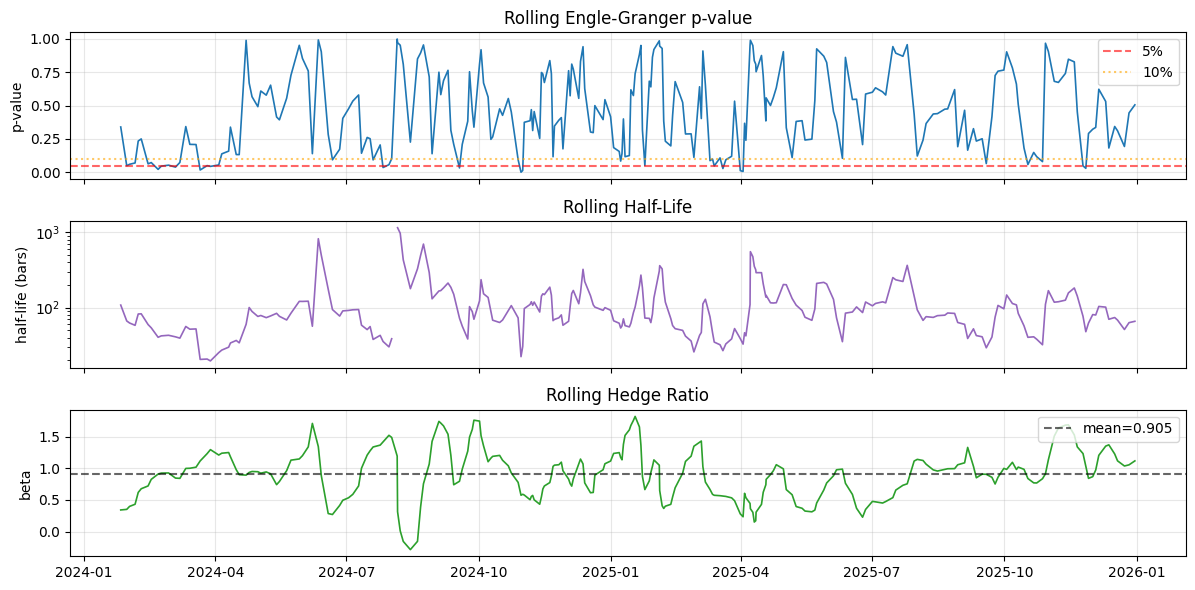

In [14]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [15]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [16]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 0.9565 | AR: 0.9669
[2024-02-27] Beta: 1.0537 | AR: 0.9764
[2024-03-12] Beta: 1.5811 | AR: 0.9689
[2024-03-26] Beta: 1.3827 | AR: 0.9586
[2024-04-09] Beta: 1.0244 | AR: 0.9624
[2024-04-23] Beta: 1.7916 | AR: 0.9822
[2024-05-07] Beta: 0.8457 | AR: 0.9804
[2024-05-21] Beta: 1.4145 | AR: 0.9798
[2024-06-04] Beta: 0.7291 | AR: 0.9710
[2024-06-18] Beta: 0.8620 | AR: 0.9817
[2024-07-02] Beta: 0.4709 | AR: 0.9810
[2024-07-16] Beta: 1.4408 | AR: 0.9796
[2024-07-30] Beta: 0.8449 | AR: 0.9754
[2024-08-13] Beta: 0.9988 | AR: 0.9827
[2024-08-27] Beta: 1.3068 | AR: 0.9859
[2024-09-10] Beta: 1.1812 | AR: 0.9847
[2024-09-24] Beta: 0.2562 | AR: 0.9791
[2024-10-08] Beta: 0.8943 | AR: 0.9770
[2024-10-22] Beta: 0.7809 | AR: 0.9766
[2024-11-05] Beta: 0.9758 | AR: 0.9768
[2024-11-19] Beta: 0.8679 | AR: 0.9829
[2024-12-03] Beta: 0.4442 | AR: 0.9823
[2024-12-17] Beta: 0.1871 | AR: 0.9839
[2025-01-02] Beta: 0.6762 | AR: 0.9840

In [17]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | 2196.88      | 1982.78      | 1197.54      |
Annual Return (bps)            | 1132.14      | 1021.80      | 617.14       |
Annual Volatility (bps)        | 576.21       | 555.84       | 542.48       |
Max Drawdown (bps)             | -335.18      | -370.57      | -377.27      |
Sharpe Ratio                   | 1.96         | 1.84         | 1.14         |
Sortino Ratio                  | 2.36         | 2.12         | 1.28         |
Calmar Ratio                   | 3.38         | 2.76         | 1.64         |
Gross Profit (bps)             | 47926.15     | 44926.86     | 43570.63     |
Gross Loss (bps)               | 45729.27     | 42944.08     | 42373.09     |
Profit Factor                  | 1.05 

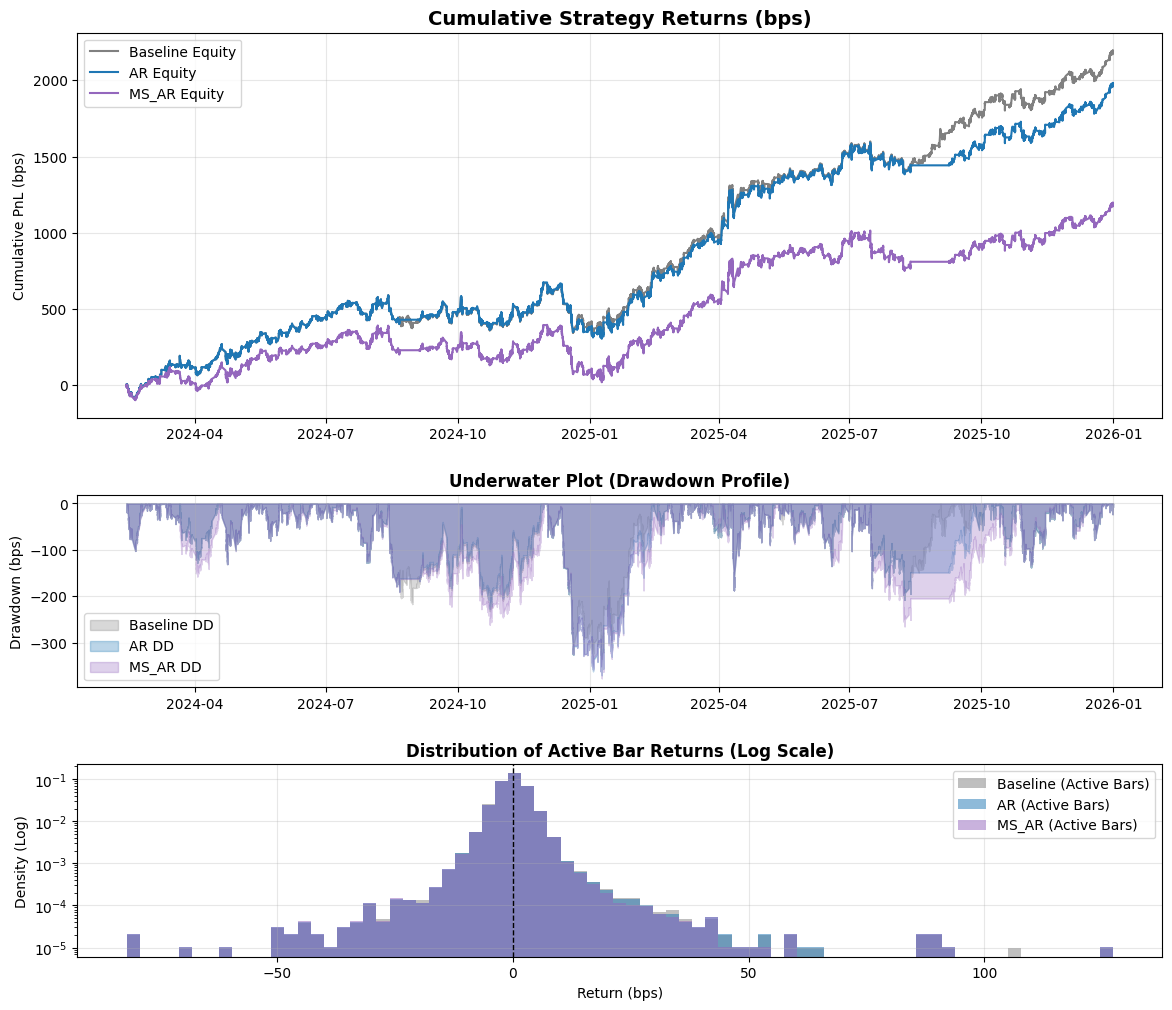

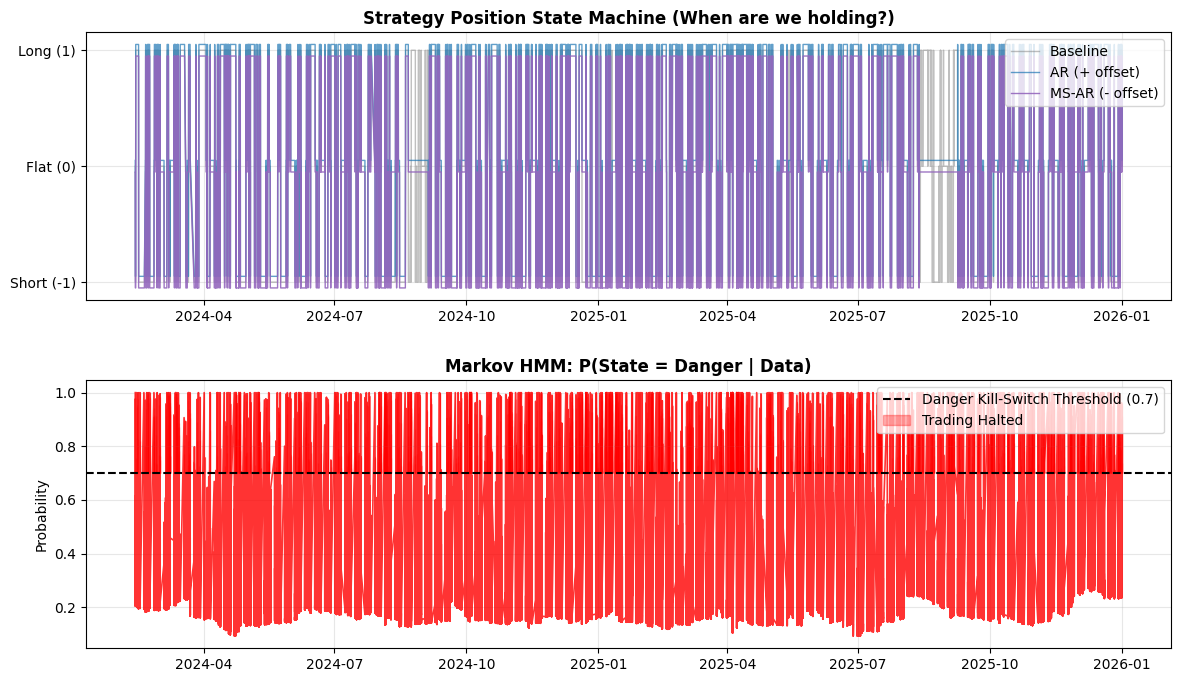

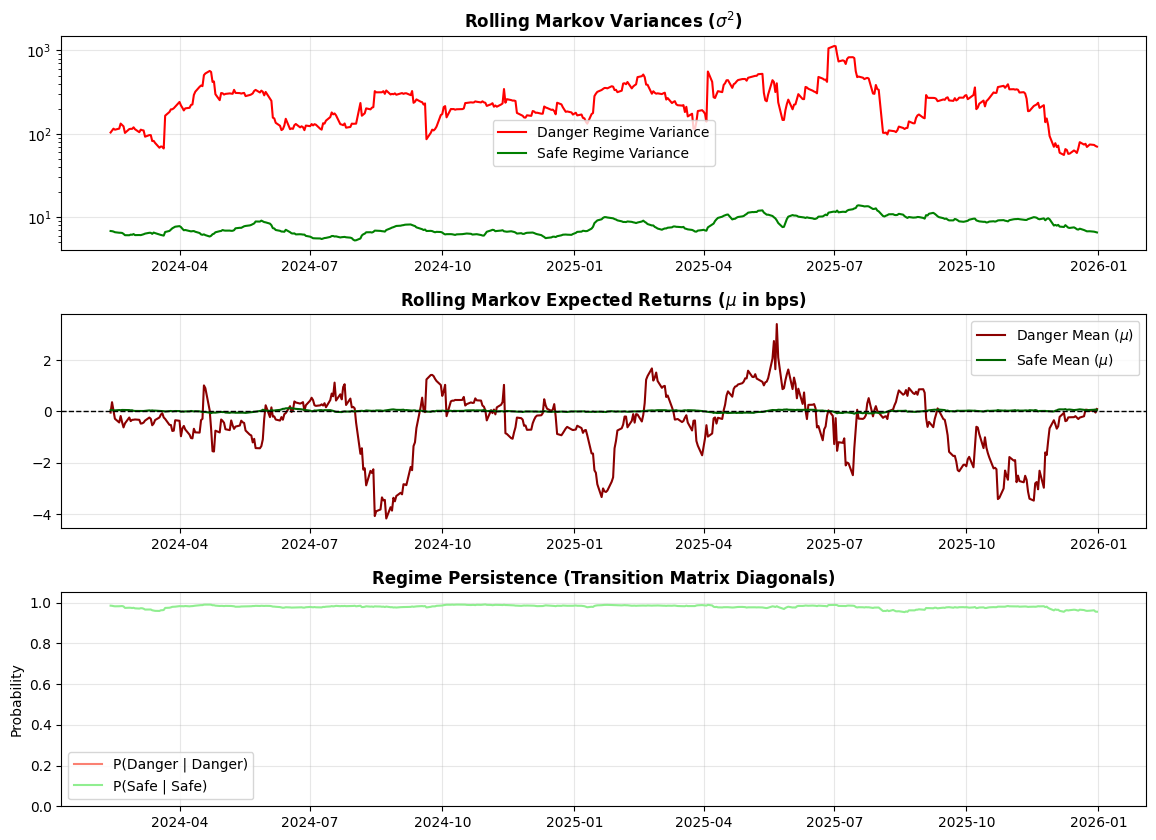

In [18]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()